# Composite Risk Index (CRI) Analysis for All Vulnerability Scenarios

This is the central notebook for the proposed methodology which computes the Composite Risk Index (CRI) for all four vulnerability scenarios in the multi-layer datasets, creates visualizations, and saves the results for further processing.

## Overview
- **Data Source**: Lisbon multi-layer vulnerability data with 4 scenarios (s1-s4)
- **CRI Formula**: `priority = core_score * (1 + gamma * equity_score)`
- **Visualization**: 4 comparative maps with contextily basemaps
- **Output**: Updated GeoJSON with CRI values for all scenarios

In [ ]:
# Import Required Libraries
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting parameters
plt.rcParams.update(
    {
        "font.size": 16,
        "font.family": "Times New Roman",
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "mathtext.fontset": "stix",
        "mathtext.rm": "Times New Roman",
    }
)

print("Libraries imported successfully!")
print(f"GeoPandas version: {gpd.__version__}")
print(f"Contextily version: {cx.__version__}")

/Volumes/Hercules/Developer/multilayer-priority/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Libraries imported successfully!
GeoPandas version: 1.0.1
Contextily version: 1.6.2


In [ ]:
city = "Lisbon"

In [15]:
# Load GeoJSON Data
data_path = f"../data/multi_layers/{city}_multi_layer_all_scenarios.geojson"

print("Loading multi-layer vulnerability data...")
gdf = gpd.read_file(data_path)

print(f"Data loaded successfully!")
print(f"Shape: {gdf.shape}")
print(f"CRS: {gdf.crs}")
print(f"\nColumns: {list(gdf.columns)}")

# Display basic statistics
print("\n=== Data Overview ===")
print(gdf.describe())

# Check for vulnerability scenarios
scenario_cols = [col for col in gdf.columns if 's1_' in col or 's2_' in col or 's3_' in col or 's4_' in col]
print(f"\nVulnerability scenario columns found: {len(scenario_cols)}")
for col in sorted(scenario_cols):
    print(f"  - {col}")

Loading multi-layer vulnerability data...
Data loaded successfully!
Shape: (6569, 10)
CRS: EPSG:4326

Columns: ['hex_id', 'response_value', 'risk_value', 'vulnerability_s1_value', 'vulnerability_s2_value', 'vulnerability_s3_value', 'vulnerability_s4_value', 'gini_value', 'income_value', 'geometry']

=== Data Overview ===
       response_value   risk_value  vulnerability_s1_value  \
count     6569.000000  6569.000000             6569.000000   
mean         0.289904     1.381195                0.173610   
std          0.173595     0.674120                0.141178   
min          0.000000     0.122230                0.003276   
25%          0.161811     0.926885                0.072934   
50%          0.271615     1.123745                0.128117   
75%          0.380285     1.897886                0.235639   
max          1.000000     2.595304                0.935261   

       vulnerability_s2_value  vulnerability_s3_value  vulnerability_s4_value  \
count             6569.000000        

In [ ]:
from scipy.stats import entropy

# Define CRI Computation Functions

def normalize_values(series, method='min-max', relatioship='positive'):
    """
    Normalize values to 0-1 range
    """
    if method == 'min-max':
        if relatioship == 'positive':
            return (series - series.min()) / (series.max() - series.min())
        elif relatioship == 'negative':
            return (series.max() - series) / (series.max() - series.min())
    elif method == 'z-score':
        return stats.zscore(series)
    else:
        raise ValueError("Method must be 'min-max' or 'z-score'")


def compute_entropy_weights(data_matrix):
    """
    Compute entropy-based weights for indicators using Shannon entropy
    from scipy.stats library for consistency and robustness
    """
    # Handle potential zeros and negative values by adding small constant
    epsilon = 1e-10
    data_matrix = np.maximum(data_matrix, epsilon)

    # Normalize data to create probability distributions for each indicator
    # Each column should sum to 1 (probability distribution)
    prob_matrix = data_matrix / data_matrix.sum(axis=0)

    # Compute Shannon entropy for each column (indicator) using scipy
    shannon_entropy = np.array(
        [entropy(prob_matrix[:, i], base=np.e) for i in range(prob_matrix.shape[1])]
    )

    # Compute maximum possible entropy (when all values are equal)
    max_entropy = np.log(len(data_matrix))

    # Normalize entropy to 0-1 range
    normalized_entropy = shannon_entropy / max_entropy

    # Handle edge case where entropy is maximum (all values equal)
    # In this case, assign equal weights
    if np.allclose(normalized_entropy, 1.0):
        weights = np.ones(len(normalized_entropy)) / len(normalized_entropy)
    else:
        # Compute weights (higher entropy = lower weight, lower diversity = higher weight)
        diversity = 1 - normalized_entropy
        weights = diversity / diversity.sum()

    return weights, shannon_entropy, normalized_entropy


def compute_cri(vulnerability, response, risk, gini, income, gamma=0.5):
    """
    Compute Composite Risk Index using the formula:
    CRI = core_score * (1 + gamma * equity_score)

    Parameters:
    - vulnerability, response, risk: core vulnerability indicators
    - gini, income: equity indicators
    - gamma: equity weight parameter

    Returns:
    - cri: Composite Risk Index values
    - core_score: Core vulnerability score
    - equity_score: Equity score
    - core_weights: Weights used for core indicators
    - equity_weights: Weights used for equity indicators
    - entropy_info: Dictionary with detailed entropy information
    """
    # Normalize all indicators to 0-1 range
    vuln_norm = normalize_values(vulnerability)
    resp_norm = normalize_values(response)
    risk_norm = normalize_values(risk)
    gini_norm = normalize_values(gini, relatioship="negative")
    income_norm = normalize_values(income, relatioship="positive")

    # Compute core score (entropy-weighted average of vulnerability indicators)
    core_indicators = np.column_stack([vuln_norm, resp_norm, risk_norm])
    core_weights, core_entropy, core_norm_entropy = compute_entropy_weights(
        core_indicators
    )
    core_score = np.average(core_indicators, axis=1, weights=core_weights)

    # Compute equity score (entropy-weighted average of equity indicators)
    equity_indicators = np.column_stack([gini_norm, income_norm])
    equity_weights, equity_entropy, equity_norm_entropy = compute_entropy_weights(
        equity_indicators
    )
    equity_score = np.average(equity_indicators, axis=1, weights=equity_weights)

    all_indicators = np.column_stack([vuln_norm, resp_norm, risk_norm, gini_norm, income_norm])
    all_weights, all_entropy, all_norm_entropy = compute_entropy_weights(all_indicators)
    all_score = np.average(all_indicators, axis=1, weights=all_weights)

    # Compute final CRI
    cri = core_score * (1 + gamma * equity_score)

    # Normalize CRI to 0-1 range
    cri = normalize_values(cri, method='min-max', relatioship='positive')
    cri = pd.Series(cri, index=vulnerability.index, name='CRI')
    cri = cri.clip(lower=0, upper=1)  # Ensure CRI is within [0, 1]

    # Prepare detailed entropy information
    entropy_info = {
        "core_entropy": core_entropy,
        "core_normalized_entropy": core_norm_entropy,
        "equity_entropy": equity_entropy,
        "equity_normalized_entropy": equity_norm_entropy,
        "core_indicator_names": ["vulnerability", "response", "risk"],
        "equity_indicator_names": ["gini", "income"],
    }

    return cri, core_score, equity_score, core_weights, equity_weights, entropy_info


print("CRI computation functions defined successfully!")
print("\nCRI Formula: priority = core_score * (1 + gamma * equity_score)")
print("- Core indicators: vulnerability, response, risk (entropy-weighted)")
print("- Equity indicators: gini, income (entropy-weighted)")
print("- Gamma parameter: 0.4 (adjustable equity weight)")

CRI computation functions defined successfully!

CRI Formula: priority = core_score * (1 + gamma * equity_score)
- Core indicators: vulnerability, response, risk (entropy-weighted)
- Equity indicators: gini, income (entropy-weighted)
- Gamma parameter: 0.4 (adjustable equity weight)


In [17]:
# Cell: Gamma Sensitivity Analysis for Priority Rankings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

# Define city name for analysis
city = "Lisbon"

print(f"=== Gamma Sensitivity Analysis for {city} ===")
print(f"Total zones in dataset: {len(gdf)}")

# Check if CRI has been computed for scenarios
scenarios = ["s1", "s2", "s3", "s4"]
available_scenarios = [s for s in scenarios if f"{s}_cri" in gdf.columns]

if not available_scenarios:
    print("⚠️ No CRI values found! Please run the CRI computation cell first.")
else:
    print(f"Available scenarios for analysis: {available_scenarios}")

# Select first available scenario for gamma sensitivity analysis
if available_scenarios:
    selected_scenario = available_scenarios[0]  # Use first available scenario
    print(f"Using scenario {selected_scenario.upper()} for gamma sensitivity analysis")

    # Extract core and equity scores from the selected scenario
    core_scores = gdf[f"{selected_scenario}_core_score"].values
    equity_scores = gdf[f"{selected_scenario}_equity_score"].values
    zone_ids = gdf["hex_id"].values

    # Define gamma sweep with more granular steps
    gamma_values = np.linspace(0, 1, num=21)  # More detailed analysis

    # DataFrame to hold ranking positions
    rankings = pd.DataFrame({"Zone": zone_ids})

    print("\nCalculating priority scores for different gamma values...")
    for i, gamma in enumerate(gamma_values):
        # Use the CRI priority calculation formula
        priority_scores = core_scores * (1 + gamma * equity_scores)

        # Normalize the priority scores
        priority_scores_norm = (priority_scores - priority_scores.min()) / (
            priority_scores.max() - priority_scores.min()
        )

        temp_df = (
            pd.DataFrame(
                {"Zone": zone_ids, f"Priority_γ={gamma:.2f}": priority_scores_norm}
            )
            .sort_values(by=f"Priority_γ={gamma:.2f}", ascending=False)
            .reset_index(drop=True)
        )
        temp_df[f"Rank_γ={gamma:.2f}"] = temp_df.index + 1
        rankings = rankings.merge(temp_df[["Zone", f"Rank_γ={gamma:.2f}"]], on="Zone")

        if i % 5 == 0:  # Progress indicator
            print(f"Processed gamma = {gamma:.2f}")

    print("Creating visualization...")

    # Select a subset of zones for better visualization (top 100 by average ranking)
    rank_cols = [col for col in rankings.columns if col.startswith("Rank_")]
    rankings["avg_rank"] = rankings[rank_cols].mean(axis=1)
    top_zones = rankings.nsmallest(100, "avg_rank")

    # Reshape for heatmap (using subset)
    rank_matrix = top_zones.set_index("Zone")[rank_cols].T
    rank_matrix.index.name = "Gamma"

    # Plot heatmap of ranking variation
    plt.figure(figsize=(20, 10))
    sns.heatmap(
        rank_matrix.astype(float),
        cmap="viridis_r",
        cbar_kws={"label": "Priority Rank"},
        linewidths=0.02,
        xticklabels=False,  # Too many zones to show labels
    )
    plt.title(
        f"{city} Zone Priority Rank Variation Across γ Values\n"
        f"(Top 100 Zones by Average Priority - Scenario {selected_scenario.upper()})",
        fontsize=16,
    )
    plt.xlabel("Zones (Hex IDs)", fontsize=12)
    plt.ylabel("γ (Equity Boost Factor)", fontsize=12)

    # Customize y-axis to show gamma values more clearly
    ytick_positions = np.arange(0, len(gamma_values), 4)
    ytick_labels = [f"{gamma_values[i]:.2f}" for i in ytick_positions]
    plt.yticks(ytick_positions, ytick_labels)

    plt.tight_layout()
    plt.show()

    # Show statistics about ranking changes
    print(
        f"\nRanking Variation Analysis for {city} (Scenario {selected_scenario.upper()}):"
    )
    print(f"Total zones analyzed: {len(rankings)}")
    print(f"Gamma range: {gamma_values.min():.2f} to {gamma_values.max():.2f}")

    # Calculate ranking stability metrics
    rank_std = rankings[rank_cols].std(axis=1)
    print(f"\nRanking Stability:")
    print(
        f"- Zones with most stable rankings (low std): {rank_std.nsmallest(5).index.tolist()}"
    )
    print(
        f"- Zones with most volatile rankings (high std): {rank_std.nlargest(5).index.tolist()}"
    )
    print(f"- Average ranking standard deviation: {rank_std.mean():.2f}")
    print(f"- Maximum ranking change: {rank_std.max():.2f} positions")

    # Additional analysis: Show top 10 zones across different gamma values
    print(f"\n🏆 Top 10 Priority Zones Across Different γ Values:")
    print("=" * 70)

    gamma_samples = [0.0, 0.25, 0.5, 0.75, 1.0]  # Sample gamma values
    for gamma in gamma_samples:
        gamma_col = f"Rank_γ={gamma:.2f}"
        if gamma_col in rankings.columns:
            top_10 = rankings.nsmallest(10, gamma_col)
            zone_list = top_10["Zone"].tolist()
            print(f"γ = {gamma:.2f}: {zone_list}")

    # Create a comparison of rankings at different gamma values
    print(f"\n📊 Ranking Comparison Summary:")
    gamma_comparison = pd.DataFrame()
    for gamma in gamma_samples:
        gamma_col = f"Rank_γ={gamma:.2f}"
        if gamma_col in rankings.columns:
            top_20 = rankings.nsmallest(20, gamma_col)["Zone"].tolist()
            gamma_comparison[f"γ={gamma:.2f}"] = top_20

    print("Top 20 zones for selected gamma values:")
    print(gamma_comparison.head(10))  # Show first 10 rows

    print("\n✅ Gamma sensitivity analysis completed!")
    print(
        f"📈 Analysis shows ranking stability across γ = [0, 1] for scenario {selected_scenario.upper()}"
    )

=== Gamma Sensitivity Analysis for Lisbon ===
Total zones in dataset: 6569
⚠️ No CRI values found! Please run the CRI computation cell first.


In [ ]:
# Compute CRI for All Four Scenarios

scenarios = ["s1", "s2", "s3", "s4"]
gamma = 0.5  # Equity weight parameter

print("Computing CRI for all vulnerability scenarios...")
print(f"Using gamma = {gamma} for equity weighting")
print(f"Using scipy.stats.entropy for Shannon entropy calculation")
print("\n" + "=" * 60)

# Store entropy information for analysis
entropy_results = {}

for scenario in scenarios:
    print(f"\nProcessing Scenario {scenario.upper()}:")

    # Get scenario-specific columns
    vuln_col = f"vulnerability_{scenario}_value"
    resp_col = "response_value"
    risk_col = "risk_value"
    gini_col = "gini_value"
    income_col = "income_value"

    # Check if all required columns exist
    required_cols = [vuln_col, resp_col, risk_col, gini_col, income_col]
    missing_cols = [col for col in required_cols if col not in gdf.columns]

    if missing_cols:
        print(f"  ⚠️  Missing columns: {missing_cols}")
        continue

    # Compute CRI for this scenario
    cri, core_score, equity_score, core_weights, equity_weights, entropy_info = (
        compute_cri(
            vulnerability=gdf[vuln_col],
            response=gdf[resp_col],
            risk=gdf[risk_col],
            gini=gdf[gini_col],
            income=gdf[income_col],
            gamma=gamma,
        )
    )

    # Store entropy information
    entropy_results[scenario] = entropy_info

    # Add results to GeoDataFrame
    gdf[f"{scenario}_cri"] = cri
    gdf[f"{scenario}_core_score"] = core_score
    gdf[f"{scenario}_equity_score"] = equity_score

    # Display statistics
    print(f"  ✓ CRI computed successfully for scenario {scenario.upper()}")
    print(f"  📊 CRI Statistics:")
    print(f"     Mean: {cri.mean():.4f}")
    print(f"     Std:  {cri.std():.4f}")
    print(f"     Min:  {cri.min():.4f}")
    print(f"     Max:  {cri.max():.4f}")
    print(f"  ⚖️  Core weights: {core_weights.round(4)}")
    print(f"  🏛️  Equity weights: {equity_weights.round(4)}")
    print(f"  📈 Core entropies: {entropy_info['core_entropy'].round(4)}")
    print(f"  📈 Equity entropies: {entropy_info['equity_entropy'].round(4)}")

print("\n" + "=" * 60)
print("🎉 CRI computation completed for all scenarios!")

# Display detailed entropy analysis
print(f"\n📊 Detailed Entropy Analysis:")
print("\n" + "-" * 50)

for scenario in scenarios:
    if scenario in entropy_results:
        info = entropy_results[scenario]
        print(f"\nScenario {scenario.upper()}:")
        print(f"  Core Indicators:")
        for i, name in enumerate(info["core_indicator_names"]):
            entropy_val = info["core_entropy"][i]
            norm_entropy = info["core_normalized_entropy"][i]
            print(
                f"    {name:12}: entropy={entropy_val:.4f}, normalized={norm_entropy:.4f}"
            )

        print(f"  Equity Indicators:")
        for i, name in enumerate(info["equity_indicator_names"]):
            entropy_val = info["equity_entropy"][i]
            norm_entropy = info["equity_normalized_entropy"][i]
            print(
                f"    {name:12}: entropy={entropy_val:.4f}, normalized={norm_entropy:.4f}"
            )

Computing CRI for all vulnerability scenarios...
Using gamma = 0.5 for equity weighting
Using scipy.stats.entropy for Shannon entropy calculation


Processing Scenario S1:
  ✓ CRI computed using scipy.stats.entropy
  📊 CRI Statistics:
     Mean: 0.3645
     Std:  0.1916
     Min:  0.0000
     Max:  1.0000
  ⚖️  Core weights: [0.4818 0.2903 0.2279]
  🏛️  Equity weights: [0.439 0.561]
  📈 Core entropies: [8.4954 8.6125 8.6507]
  📈 Equity entropies: [8.6247 8.5788]

Processing Scenario S2:
  ✓ CRI computed using scipy.stats.entropy
  📊 CRI Statistics:
     Mean: 0.4003
     Std:  0.1833
     Min:  0.0000
     Max:  1.0000
  ⚖️  Core weights: [0.1392 0.4822 0.3786]
  🏛️  Equity weights: [0.439 0.561]
  📈 Core entropies: [8.7389 8.6125 8.6507]
  📈 Equity entropies: [8.6247 8.5788]

Processing Scenario S3:
  ✓ CRI computed using scipy.stats.entropy
  📊 CRI Statistics:
     Mean: 0.4055
     Std:  0.1802
     Min:  0.0000
     Max:  1.0000
  ⚖️  Core weights: [0.1359 0.4841 0.38  ]
  🏛️  Equi

In [52]:
# Visualization Functions
def plot_scenario_map(gdf, scenario, cri_column, title_suffix="", figsize=(15, 10)):
    """
    Plot CRI map for a specific scenario with contextily basemap
    """
    # Ensure CRS is Web Mercator for contextily
    gdf_web_mercator = gdf.to_crs(epsg=3857)

    # Create figure and axis
    fig, ax = plt.subplots(figsize=figsize)

    # Plot the data
    gdf_web_mercator.plot(
        column=cri_column,
        cmap="turbo",
        linewidth=0.0,
        edgecolor="white",
        alpha=0.8,
        ax=ax,
        legend=True,
        legend_kwds={
            "label": "Composite Risk Index (CRI)",
            "orientation": "vertical",
            "shrink": 0.8,
            "aspect": 30,
            "pad": 0.03,
        },
    )

    # Add contextily basemap
    try:
        cx.add_basemap(
            ax, crs=gdf_web_mercator.crs, source=cx.providers.CartoDB.Voyager, alpha=0.7
        )
        basemap_info = "CartoDB Voyager"
    except Exception as e:
        print(f"Warning: Could not add basemap - {e}")
        basemap_info = "No basemap"

    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)

    # Remove axis ticks for cleaner look
    ax.set_xticks([])
    ax.set_yticks([])

    plt.tight_layout()
    return fig, ax

def create_comparison_plot(gdf, scenarios, figsize=(10, 20)):
    """
    Create a 2x2 comparison plot of all scenarios
    """
    fig, axes = plt.subplots(1, 4, figsize=figsize)
    axes = axes.flatten()

    # Ensure CRS is Web Mercator for contextily
    gdf_web_mercator = gdf.to_crs(epsg=3857)

    for i, scenario in enumerate(scenarios):
        ax = axes[i]
        cri_column = f'{scenario}_cri'

        # Plot the data
        gdf_web_mercator.plot(
            column=cri_column,
            cmap="turbo",
            linewidth=0.0,
            edgecolor="white",
            alpha=0.8,
            ax=ax,
            legend=True,
            legend_kwds={
            # "label": "CRI$_{ent}$",
            "label": "Entropy-weighted CRI",
            "orientation": "horizontal",
            "shrink": 0.8,
            "aspect": 20,
            "pad": 0.03,
            },
        )

        # Add contextily basemap
        try:
            cx.add_basemap(
                ax,
                crs=gdf_web_mercator.crs,
                source=cx.providers.CartoDB.Voyager,
                alpha=0.7,
            )
        except Exception as e:
            print(f"Warning: Could not add basemap for {scenario} - {e}")

        # Customize subplot
        ax.set_title(f"Scenario {scenario[1:]}", fontsize=14)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    return fig

print("Visualization functions defined successfully!")
print("Functions available:")
print("  - plot_scenario_map(): Individual scenario mapping")
print("  - create_comparison_plot(): 1x4 comparison visualization")

Visualization functions defined successfully!
Functions available:
  - plot_scenario_map(): Individual scenario mapping
  - create_comparison_plot(): 1x4 comparison visualization


Generating individual CRI maps for all scenarios...


📍 Creating map for Scenario S1...


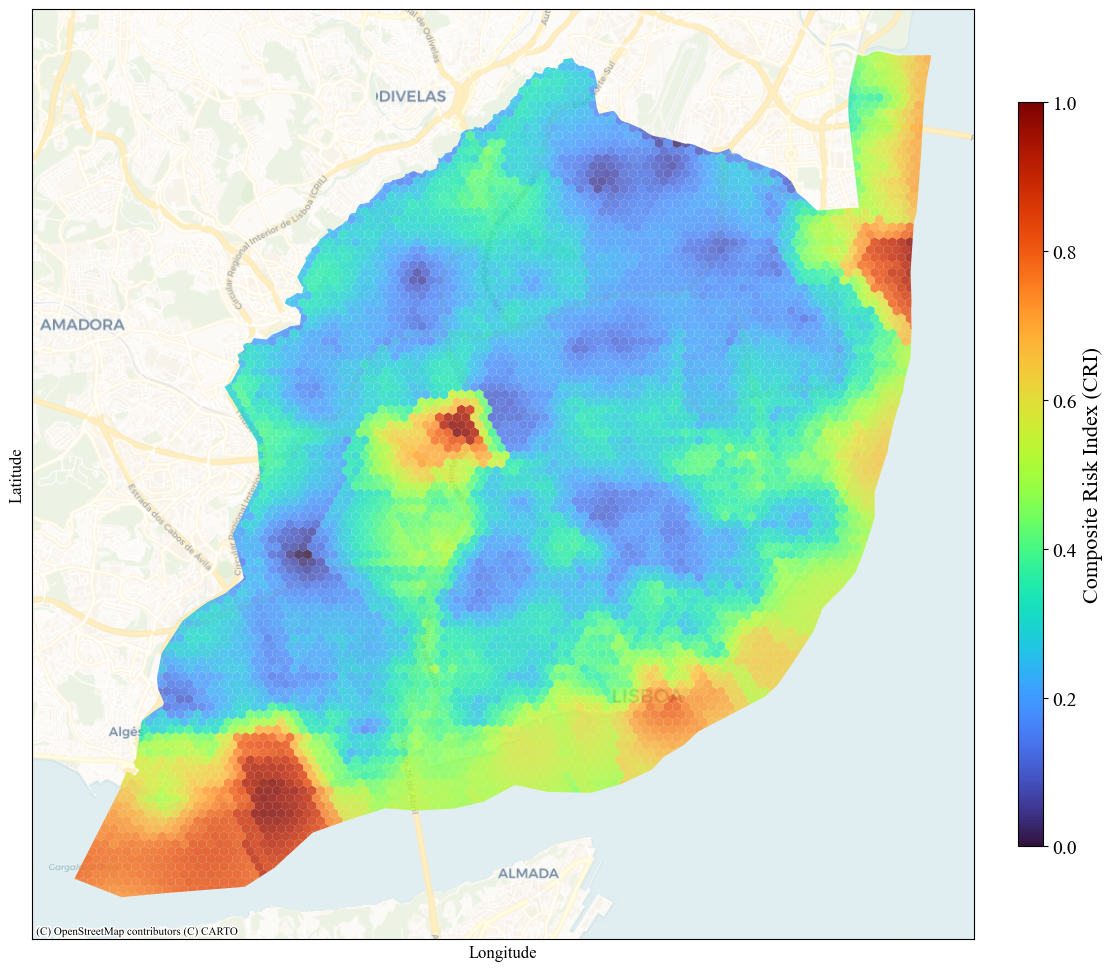

  ✓ Map completed for Scenario S1

📍 Creating map for Scenario S2...


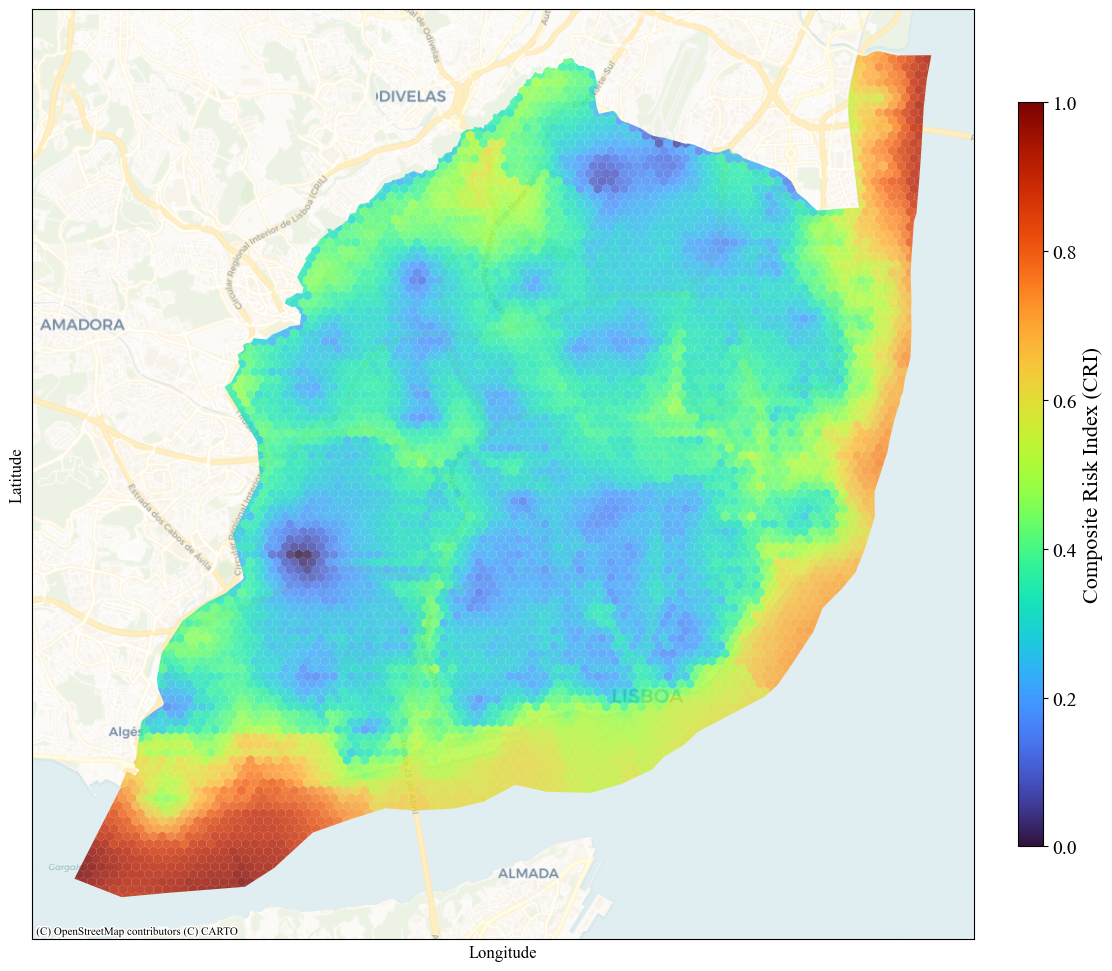

  ✓ Map completed for Scenario S2

📍 Creating map for Scenario S3...


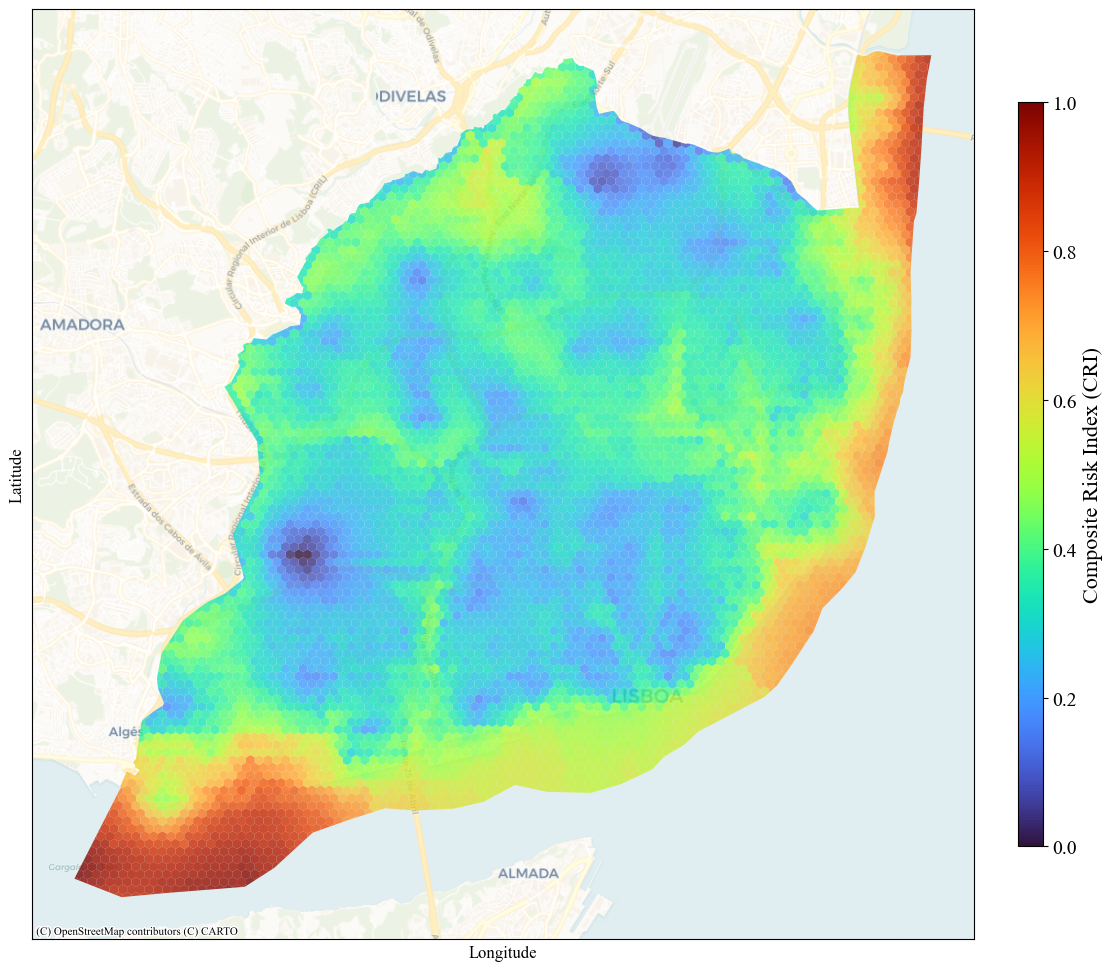

  ✓ Map completed for Scenario S3

📍 Creating map for Scenario S4...


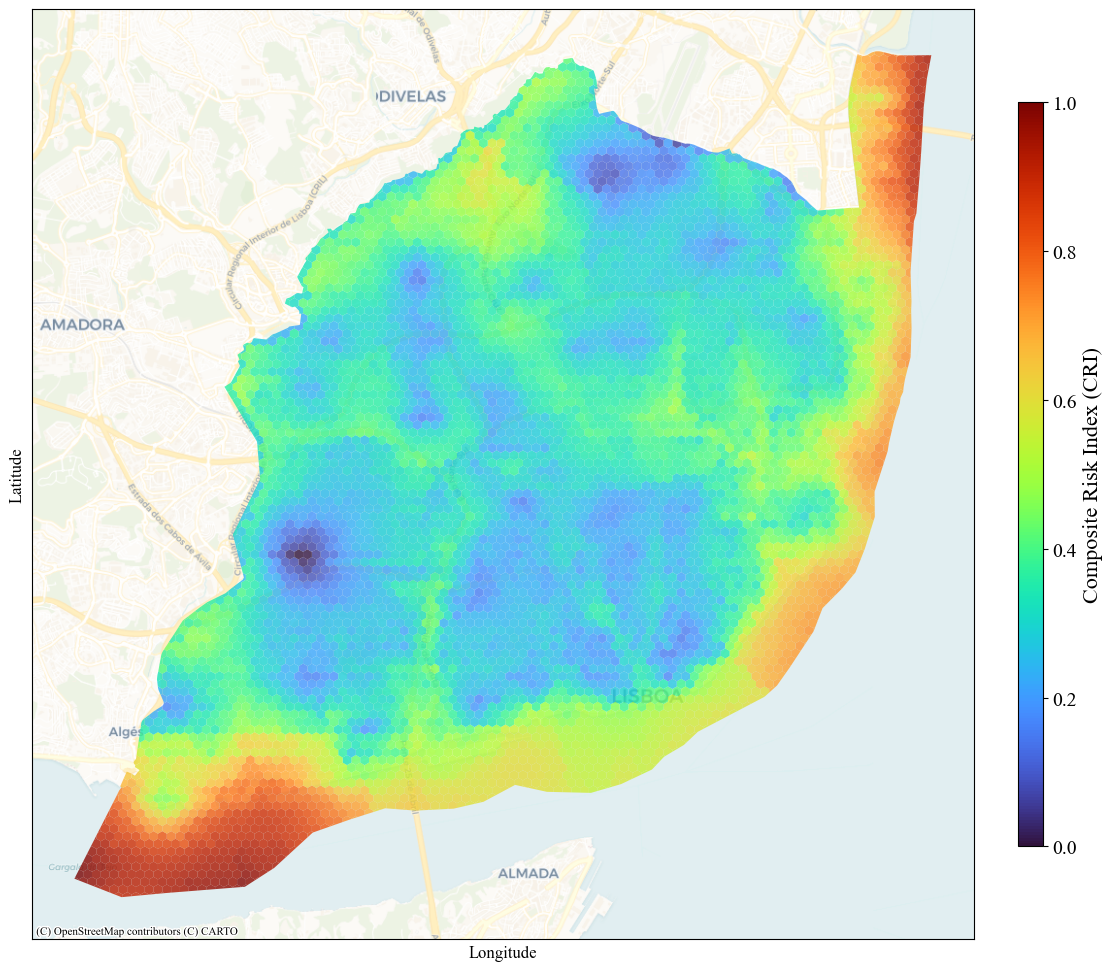

  ✓ Map completed for Scenario S4

🗺️  Individual scenario maps generated successfully!


In [50]:
# Generate Individual Maps for Each Scenario

print("Generating individual CRI maps for all scenarios...")
print("\n" + "="*50)

for scenario in scenarios:
    cri_column = f'{scenario}_cri'
    
    if cri_column in gdf.columns:
        print(f"\n📍 Creating map for Scenario {scenario.upper()}...")
        
        fig, ax = plot_scenario_map(
            gdf, 
            scenario, 
            cri_column, 
            title_suffix=f" ({len(gdf)} hexagonal units)"
        )
        
        plt.show()
        print(f"  ✓ Map completed for Scenario {scenario.upper()}")
    else:
        print(f"  ⚠️  CRI column not found for Scenario {scenario.upper()}")

print("\n" + "="*50)
print("🗺️  Individual scenario maps generated successfully!")

Creating comparison visualization...
  ✓ Comparison plot saved to ../data/figures/Lisbon_cri_comparison.pdf


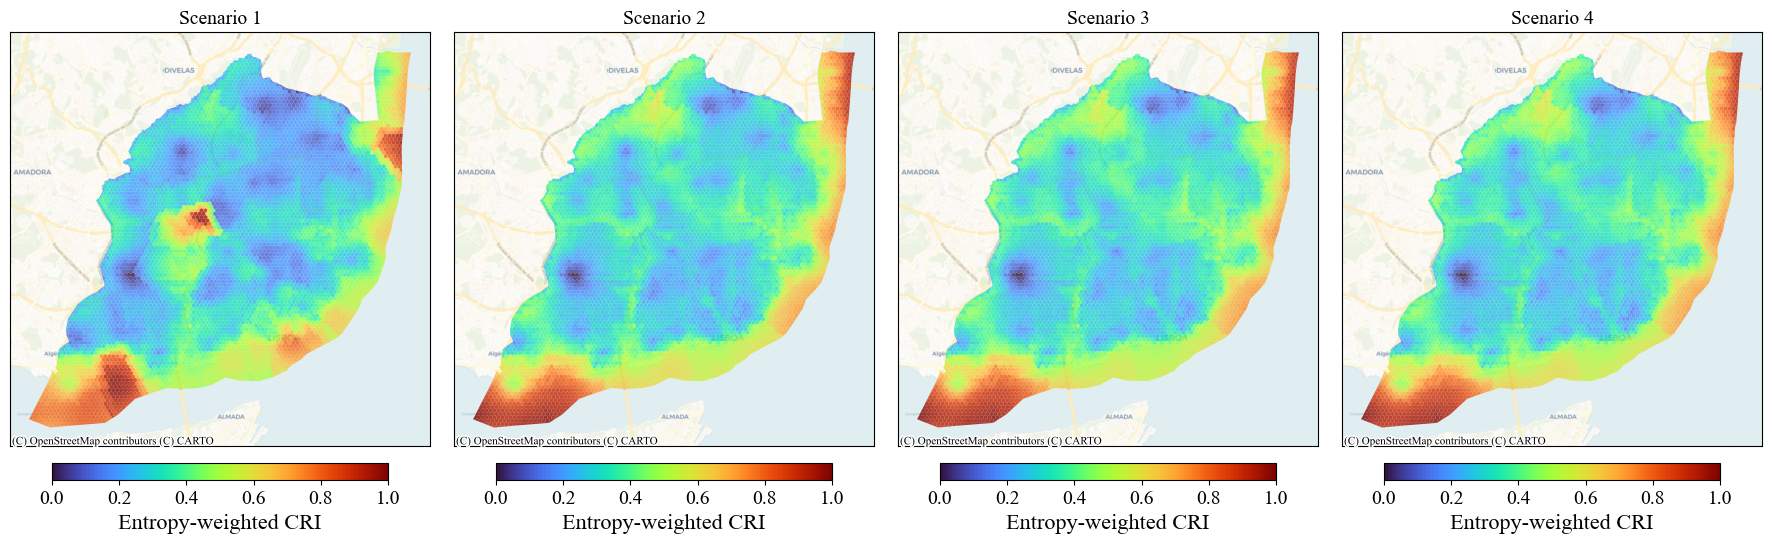

✓ Comparison visualization completed!

📊 Summary of CRI values across all scenarios:

------------------------------------------------------------
      Mean     Std     Min     Max     Q25     Q75
S1  0.3645  0.1916  0.0000  1.0000  0.2245  0.4736
S2  0.4003  0.1833  0.0000  1.0000  0.2713  0.4879
S3  0.4055  0.1802  0.0000  1.0000  0.2791  0.4867
S4  0.4030  0.1808  0.0000  1.0000  0.2754  0.4889

------------------------------------------------------------


In [53]:
# Create Comprehensive Comparison Visualization

print("Creating comparison visualization...")

# Generate 1x4 comparison plot
fig = create_comparison_plot(gdf, scenarios, figsize=(18, 6))

# Save the plot as a PDF file
output_path = f'../data/figures/{city}_cri_comparison.pdf'
fig.savefig(output_path, bbox_inches='tight', dpi=300)
print(f"  ✓ Comparison plot saved to {output_path}")

plt.show()

print("✓ Comparison visualization completed!")
print("\n📊 Summary of CRI values across all scenarios:")
print("\n" + "-"*60)

# Create summary statistics table
summary_stats = {}
for scenario in scenarios:
    cri_column = f'{scenario}_cri'
    if cri_column in gdf.columns:
        stats = gdf[cri_column].describe()
        summary_stats[scenario.upper()] = {
            'Mean': f"{stats['mean']:.4f}",
            'Std': f"{stats['std']:.4f}",
            'Min': f"{stats['min']:.4f}",
            'Max': f"{stats['max']:.4f}",
            'Q25': f"{stats['25%']:.4f}",
            'Q75': f"{stats['75%']:.4f}"
        }

# Display summary table
summary_df = pd.DataFrame(summary_stats).T
print(summary_df)
print("\n" + "-"*60)


🔗 Analyzing CRI correlations between scenarios...

CRI Correlation Matrix:
        s1_cri  s2_cri  s3_cri  s4_cri
s1_cri  1.0000  0.8493  0.8362  0.8292
s2_cri  0.8493  1.0000  0.9964  0.9983
s3_cri  0.8362  0.9964  1.0000  0.9973
s4_cri  0.8292  0.9983  0.9973  1.0000


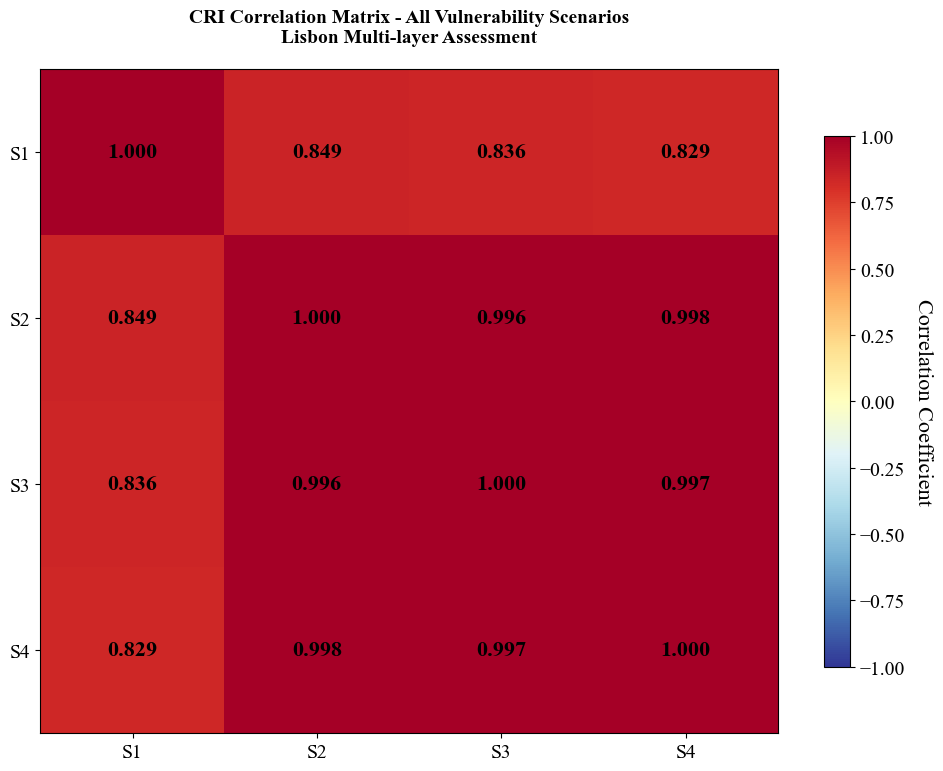


📈 Correlation analysis completed!

🔗 Highest correlation: S2 - S4 (r = 0.9983)
🔗 Lowest correlation: S1 - S4 (r = 0.8292)


In [32]:
# Analyze CRI Correlations Between Scenarios

print("\n🔗 Analyzing CRI correlations between scenarios...")

# Create correlation matrix
cri_columns = [f'{s}_cri' for s in scenarios if f'{s}_cri' in gdf.columns]
cri_data = gdf[cri_columns]

# Compute correlation matrix
corr_matrix = cri_data.corr()

print("\nCRI Correlation Matrix:")
print(corr_matrix.round(4))

# Visualize correlation matrix
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap='RdYlBu_r', aspect='auto', vmin=-1, vmax=1)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Correlation Coefficient', rotation=270, labelpad=20)

# Set labels
ax.set_xticks(range(len(cri_columns)))
ax.set_yticks(range(len(cri_columns)))
ax.set_xticklabels([col.replace('_cri', '').upper() for col in cri_columns])
ax.set_yticklabels([col.replace('_cri', '').upper() for col in cri_columns])

# Add correlation values as text
for i in range(len(cri_columns)):
    for j in range(len(cri_columns)):
        text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.3f}',
                      ha="center", va="center", color="black", fontweight='bold')

ax.set_title('CRI Correlation Matrix - All Vulnerability Scenarios\n'
            'Lisbon Multi-layer Assessment', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\n📈 Correlation analysis completed!")

# Identify most and least correlated scenarios
max_corr = 0
min_corr = 1
max_pair = None
min_pair = None

for i in range(len(scenarios)):
    for j in range(i+1, len(scenarios)):
        s1, s2 = scenarios[i], scenarios[j]
        if f'{s1}_cri' in gdf.columns and f'{s2}_cri' in gdf.columns:
            corr_val = corr_matrix.loc[f'{s1}_cri', f'{s2}_cri']
            if corr_val > max_corr:
                max_corr = corr_val
                max_pair = (s1.upper(), s2.upper())
            if corr_val < min_corr:
                min_corr = corr_val
                min_pair = (s1.upper(), s2.upper())

if max_pair and min_pair:
    print(f"\n🔗 Highest correlation: {max_pair[0]} - {max_pair[1]} (r = {max_corr:.4f})")
    print(f"🔗 Lowest correlation: {min_pair[0]} - {min_pair[1]} (r = {min_corr:.4f})")

In [55]:
# Save Updated GeoJSON with CRI Results

print("\n💾 Saving updated GeoJSON with CRI computations...")

# Define output path
output_path = f'../data/multi_layers/{city}_multi_layer_all_scenarios_with_CRI.geojson'

# Save the updated GeoDataFrame
gdf.to_file(output_path, driver='GeoJSON')

print(f"✅ Updated GeoJSON saved successfully!")
print(f"📁 Output file: {output_path}")
print(f"📊 Total records: {len(gdf)}")
print(f"🏛️ Total columns: {len(gdf.columns)}")

# Verify file size
import os
file_size_mb = os.path.getsize(output_path) / (1024 * 1024)
print(f"\n📏 Output file size: {file_size_mb:.2f} MB")

print("\n" + "="*60)
print("🎉 CRI Analysis Complete!")
print("\n📋 Summary:")
print(f"  ✓ Processed {len(scenarios)} vulnerability scenarios")
print(f"  ✓ Computed CRI using entropy-weighted indicators")
print(f"  ✓ Generated {len(scenarios) + 1} visualization maps")
print(f"  ✓ Saved results to GeoJSON format")
print("\n🔗 The updated dataset includes:")
print("  - Original vulnerability, response, risk, gini, income data")
print("  - Computed CRI values for all scenarios")
print("  - Core and equity scores for detailed analysis")
print("  - Ready for further spatial analysis and decision-making")


💾 Saving updated GeoJSON with CRI computations...
✅ Updated GeoJSON saved successfully!
📁 Output file: ../data/multi_layers/Lisbon_multi_layer_all_scenarios_with_CRI.geojson
📊 Total records: 6569
🏛️ Total columns: 22

📏 Output file size: 7.33 MB

🎉 CRI Analysis Complete!

📋 Summary:
  ✓ Processed 4 vulnerability scenarios
  ✓ Computed CRI using entropy-weighted indicators
  ✓ Generated 5 visualization maps
  ✓ Saved results to GeoJSON format

🔗 The updated dataset includes:
  - Original vulnerability, response, risk, gini, income data
  - Computed CRI values for all scenarios
  - Core and equity scores for detailed analysis
  - Ready for further spatial analysis and decision-making
